## **Session 5** - Beyond GLMs Decision Tree
درخت تصمیم مدلی غیر خطی و قدرتمند است که در ماشین لرنینگ بسیار استفاده می شود.

این مدل درواقع مانند بازی بیست سوالی کار می کند. در هر محله سوالی را مطرح می کند و بر اساس پاسخ آن با توجه به سمپل، شاخه ($Branch$) ویژه ای را در درخت دنبال می کند

برای یک مثال ساده فرض کنید میخواهیم پیش بینی کنیم که آیا فردی به توجه به آب وهوا، برای تنیس بازی بیرون می رود یا نه؟

آنگاه داریم:
```
                 Outlook
                /   |   \
              /     |     \
           Sunny  Overcast  Rain
           /         |        \
         /           |          \
    Humidity     Play=Yes      Windy
    /     \                   /     \
 High     Normal          Strong   Weak
  |         |               |        |
Play=No   Play=Yes       Play=No   Play=Yes
```

برخلاف مدل‌های خطی که از یک معادله واحد استفاده می‌کنند، درخت‌های تصمیم‌گیری می‌توانند مرزهای پیچیده تصمیم‌گیری را ثبت کرده و بینش‌هایی در مورد فرآیند تصمیم‌گیری ارائه دهند.

---

#### Components of a Decision Tree

![](images/img_12.png)

1. root node
2. internal node
3. branch
4. leaf node
5. decision path

---

Decision trees offer several unique advantages:

1. **Interpretability:** They mimic human decision-making processes, making them easy to understand and explain.
2. **Versatility:** They can handle both numerical and categorical data without extensive preprocessing.
3. **Non-linearity:** They can capture complex, non-linear relationships in the data.
4. **Feature importance:** They provide clear insights into which features are most crucial for classification.

 >حالا ما قراره چه کاری انجام بدیم؟
 >
>ما داده $(Data)$ رو داریم
>
>حالا باید از روی داده ها درخت رو بسازیم

### Building a Decision Tree
The process of building a decision tree is often referred to as "induction."

#### Top-down Induction Process
Decision trees are typically built using a top-down approach, also known as recursive partitioning. This method starts at the root node and progressively splits the data into subsets, moving down the tree.

The top-down induction process aims to create a tree that accurately classifies the training data while avoiding overfitting.

The general steps in this process are:

1. Start with the entire dataset at the root node.
2. Select the best feature to split the data.
3. Create child nodes for each possible value of the selected feature.
4. Repeat steps 2-3 for each child node until a stopping criterion is met.

*The "best" feature to split on is typically determined by a metric such as information gain or Gini impurity*

---

#### Recursive Partitioning
how it works:

1. **Feature Selection:** For each node, evaluate all available features and select the one that best splits the data according to a chosen criterion.

2. **Data Splitting:** Divide the data at the current node based on the selected feature.

3. **Child Node Creation:** Create a new child node for each possible value of the selected feature.

4. **Recursion:** For each child node, repeat steps 1-3 on the subset of data that reaches that node.

5. **Termination:** Stop when a stopping criterion is met (e.g., all samples in a node belong to the same class, or the tree reaches a maximum depth).

---

Example:
```python
def build_tree(data):
    if stopping_criterion_met(data):
        return create_leaf_node(data)

    best_feature = find_best_split(data)
    node = create_internal_node(best_feature)

    for value in unique_values(data[best_feature]):
        subset = data[data[best_feature] == value]
        child = build_tree(subset)
        add_child_to_node(node, child, value)

    return node
```

---

#### Stopping Criteria
1. Maximum Depth: Stop growing the tree once it reaches a specified maximum depth.

2. Minimum Samples per Leaf: Stop splitting if a node has fewer than a specified number of samples.

3. Minimum Impurity Decrease: Stop if a split would result in an impurity decrease less than a specified threshold.

4. Pure Node: Stop if all samples in a node belong to the same class.

---



### Splitting Criteria
یکی از مهم ترین عناصر در ساخت یک درخت تصمیم این است که بر چه اساسی داده ها را تقسیم کنیم؟

This is where splitting criteria come into play.
 These criteria help us quantify the quality of a split and choose the best feature to split on at each step.

Splitting criteria measure how well a potential split separates the classes in a dataset. The goal is to find splits that create the "purest" possible child nodes.

معیارهای تقسیم‌بندی، میزان موفقیت یک تقسیم‌بندی بالقوه در جداسازی کلاس‌ها در یک مجموعه داده را اندازه‌گیری می‌کنند. هدف، یافتن تقسیم‌بندی‌هایی است که «خالص‌ترین» گره‌های فرزند ممکن را ایجاد می‌کنند.

---

#### Entropy and Information Gain

**Entropy** is a measure of impurity or uncertainty in a set of examples. In the context of decision trees, it quantifies the disorder in the class labels of a node.

For a binary classification problem, entropy is defined as:
$$H(S) = -p_+ \log_2(p_+) - p_- \log_2(p_-)$$

Where:

- $S$ is the set of examples
- $p_+$ is the proportion of positive examples
- $p_-$ is the proportion of negative examples


**Information Gain** measures the reduction in entropy achieved by splitting on a particular feature. It's calculated as the difference between the entropy of the parent node and the weighted sum of entropies of the child nodes:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

Where:

 - $S$ is the set of examples in the parent node
 - $A$ is the feature being considered for the split
 - $S_v$ is the subset of $S$ for which feature $A$ has value $v$



### Simple Implementation Example
this is a basic and simple implementation of decision tree

In [15]:
import numpy as np
from collections import Counter

import pandas as pd
from sklearn.model_selection import train_test_split


class DecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.n_classes = len(set(y))
        self.n_features = X.shape[1]
        self.tree = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(set(y))

        # Stopping criteria
        if depth >= self.max_depth or n_labels == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'value': leaf_value}

        # Find the best split
        best_feature, best_threshold = self._best_split(X, y)

        # Split the data
        left_idxs = X[:, best_feature] < best_threshold
        right_idxs = ~left_idxs

        # Recursively grow the left and right subtree
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth+1)

        return {'feature': best_feature, 'threshold': best_threshold,
                'left': left, 'right': right}

    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        for feature in range(self.n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                gain = self._information_gain(y, X[:, feature], threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _information_gain(self, y, X_column, threshold):
        # Parent entropy
        parent_entropy = self._entropy(y)

        # Generate split
        left_idxs = X_column < threshold
        right_idxs = ~left_idxs

        if len(y[left_idxs]) == 0 or len(y[right_idxs]) == 0:
            return 0

        # Calculate the weighted avg. of the entropy for the children
        n = len(y)
        n_l, n_r = len(y[left_idxs]), len(y[right_idxs])
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # Calculate the information gain
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.tree) for x in X])

    def _traverse_tree(self, x, node):
        if 'value' in node:
            return node['value']

        if x[node['feature']] < node['threshold']:
            return self._traverse_tree(x, node['left'])
        return self._traverse_tree(x, node['right'])

    def __str__(self):
        for i, node in enumerate(self.tree):
            print(f"Node {i}: {node}")
        return ""

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# load data
iris = load_iris()
X, y = iris.data[:, [2,3]], iris.target

#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model with our implementation
dt = DecisionTree(max_depth=3)
dt.fit(X_train, y_train)

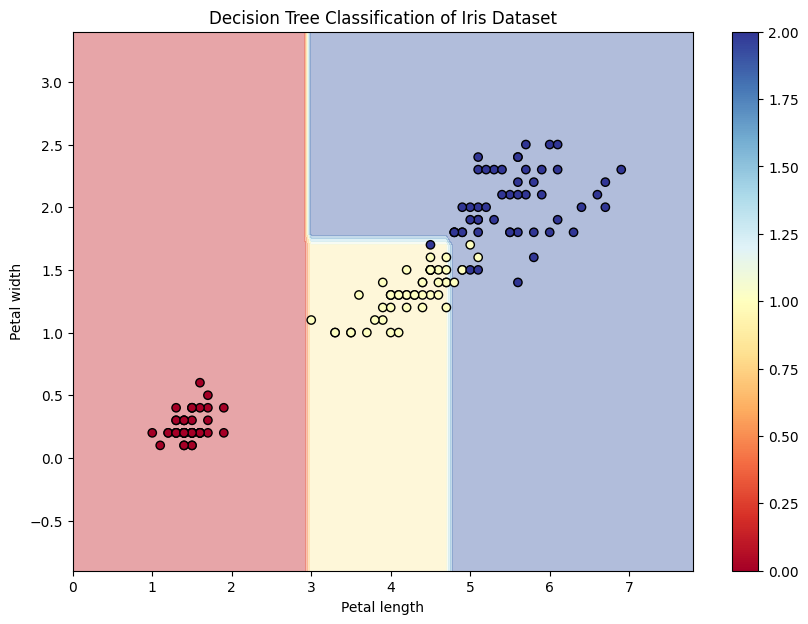

In [25]:
# Visualize the decision boundaries
def plot_decision_boundaries(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolor='black')
    plt.xlabel('Petal length')
    plt.ylabel('Petal width')
    plt.title('Decision Tree Classification of Iris Dataset')
    plt.colorbar(scatter)
    plt.show()

plot_decision_boundaries(X, y, dt)

### Implementation with **scikit-learn**
This code will produce a plot showing how the decision tree partitions the feature space to classify the Iris flowers.

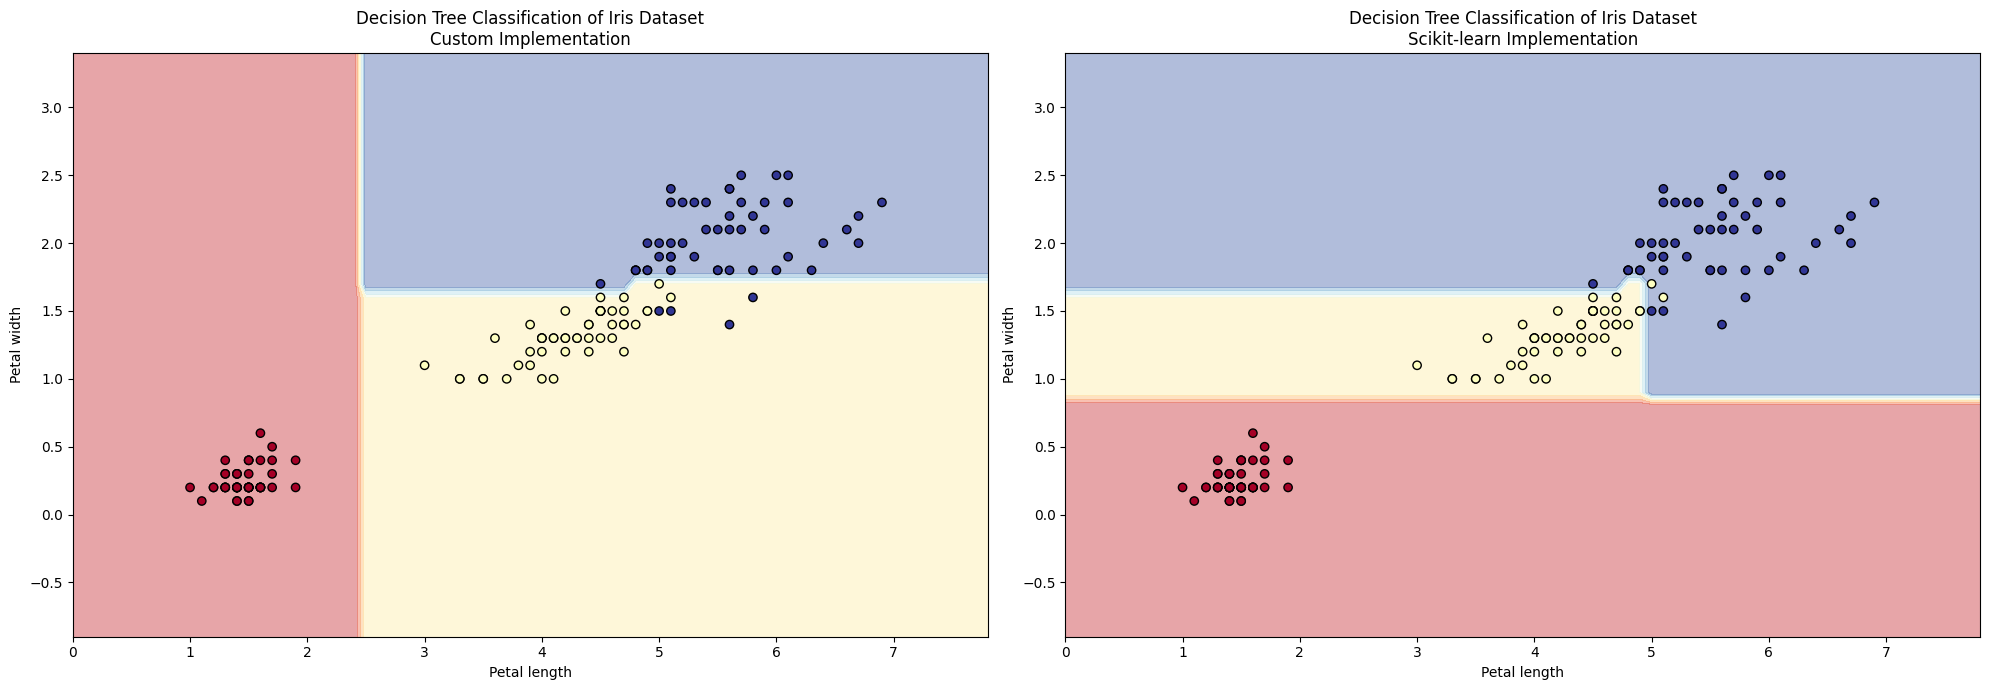

In [45]:
from sklearn.tree import DecisionTreeClassifier # import

# Train with scikit-learn classifier
dt_sklearn = DecisionTreeClassifier(max_depth=4)
dt_sklearn.fit(X_train, y_train)

# Visualize the decision boundaries
def plot_decision_boundaries(X, y, models, titles):
    fig, axs = plt.subplots(1, 2, figsize=(20, 7))

    for ax, model, title in zip(axs, models, titles):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                             np.arange(y_min, y_max, 0.1))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolor='black')
        ax.set_xlabel('Petal length')
        ax.set_ylabel('Petal width')
        ax.set_title(f'Decision Tree Classification of Iris Dataset\n{title}')

    plt.tight_layout()
    plt.show()

# Plot decision boundaries for both models
plot_decision_boundaries(X, y, [dt, dt_sklearn], ['Custom Implementation', 'Scikit-learn Implementation'])

In [46]:
# Evaluate and compare the models
def evaluate_model(model, X, y):
    predictions = model.predict(X)
    accuracy = np.mean(predictions == y)
    return accuracy

print("Custom Model Accuracy:", evaluate_model(dt, X_test, y_test))
print("Scikit-learn Model Accuracy:", evaluate_model(dt_sklearn, X_test, y_test))

Custom Model Accuracy: 1.0
Scikit-learn Model Accuracy: 1.0
